In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/fitness-tracker-dataset/gym_members_exercise_tracking_synthetic_data.csv


# Tasks: Preprocessing and EDA Steps

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## Step 1: Load the Data

In [3]:
#Load the dataset into a pandas DataFrame using pd.read_csv()
df=pd.read_csv('/kaggle/input/fitness-tracker-dataset/gym_members_exercise_tracking_synthetic_data.csv')

In [4]:
#Display the first few rows using .head() to understand the structure.
df.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,34.0,Female,86.7,1.86,174,152.0,74.0,1.12,712.0,Strength,12.8,2.4,5.0,2.0,14.31
1,26.0,Female,84.7,1.83,166,156.0,73.0,1.00,833.0,Strength,27.9,2.8,5.0,2.0,33.49
2,22.0,Male,64.8,1.85,187,166.0,64.0,1.24,1678.0,Cardio,28.7,1.9,3.0,2.0,12.73
3,54.0,Female,75.3,1.82,187,169.0,58.0,1.45,628.0,Cardio,31.8,2.4,4.0,1.0,20.37
4,34.0,Female,52.8,1.74,177,169.0,66.0,1.60,1286.0,Strength,26.4,3.2,4.0,2.0,20.83


## Step 2: Inspect the Data

In [5]:
df.shape

(1800, 15)

In [6]:
df.columns

Index(['Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM',
       'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned',
       'Workout_Type', 'Fat_Percentage', 'Water_Intake (liters)',
       'Workout_Frequency (days/week)', 'Experience_Level', 'BMI'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            1790 non-null   float64
 1   Gender                         1729 non-null   object 
 2   Weight (kg)                    1778 non-null   float64
 3   Height (m)                     1774 non-null   float64
 4   Max_BPM                        1779 non-null   object 
 5   Avg_BPM                        1770 non-null   float64
 6   Resting_BPM                    1781 non-null   float64
 7   Session_Duration (hours)       1777 non-null   float64
 8   Calories_Burned                1777 non-null   float64
 9   Workout_Type                   1739 non-null   object 
 10  Fat_Percentage                 1784 non-null   float64
 11  Water_Intake (liters)          1776 non-null   float64
 12  Workout_Frequency (days/week)  1742 non-null   f

In [8]:
df.describe()

,Age,Weight (kg),Height (m),Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
count,1790.000000,1778.000000,1774.000000,1770.000000,1781.000000,1777.000000,1777.000000,1784.000000,1776.000000,1742.000000,1743.000000,1770.000000
mean,34.475419,67.606637,1.739233,146.259322,63.951151,1.391598,1033.698931,23.509361,2.706644,3.339265,1.823867,19.957774
std,12.315728,19.861408,0.123892,15.219516,7.936502,0.372342,328.049662,5.865557,0.710224,0.947955,0.746568,6.573175
min,18.000000,40.000000,1.500000,120.000000,50.000000,0.500000,303.000000,10.000000,1.500000,2.000000,1.000000,12.320000
25%,23.000000,52.300000,1.650000,133.250000,57.000000,1.130000,794.000000,20.500000,2.100000,3.000000,1.000000,14.780000
50%,33.000000,65.300000,1.730000,146.000000,65.000000,1.370000,1030.000000,24.300000,2.800000,3.000000,2.000000,18.690000
75%,45.000000,80.100000,1.820000,160.000000,72.000000,1.640000,1249.000000,27.500000,3.400000,4.000000,2.000000,23.517500
max,59.000000,129.900000,2.000000,169.000000,74.000000,2.000000,1783.000000,35.000000,3.700000,5.000000,3.000000,49.840000


## Step 3: Identify and Handle Missing Values

In [9]:
df.isna().sum()

Age                              10
Gender                           71
Weight (kg)                      22
Height (m)                       26
Max_BPM                          21
Avg_BPM                          30
Resting_BPM                      19
Session_Duration (hours)         23
Calories_Burned                  23
Workout_Type                     61
Fat_Percentage                   16
Water_Intake (liters)            24
Workout_Frequency (days/week)    58
Experience_Level                 57
BMI                              30
dtype: int64

In [10]:
#by using .loc
mask=df["Age"].isna() #identify column containing missing vals or <df.isnull()>
df.loc[mask,'Age']=df['Age'].mean()

In [11]:
# by using fillna
df['Experience_Level'].fillna(df['Experience_Level'].mean(),inplace=True)
df['Gender'].fillna('Unknown',inplace=True)
df.isna().sum()

<ipython-input-11-e4eeb57983e5>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Experience_Level'].fillna(df['Experience_Level'].mean(),inplace=True)
<ipython-input-11-e4eeb57983e5>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value,

Age                               0
Gender                            0
Weight (kg)                      22
Height (m)                       26
Max_BPM                          21
Avg_BPM                          30
Resting_BPM                      19
Session_Duration (hours)         23
Calories_Burned                  23
Workout_Type                     61
Fat_Percentage                   16
Water_Intake (liters)            24
Workout_Frequency (days/week)    58
Experience_Level                  0
BMI                              30
dtype: int64

In [12]:
numeric_col=df.select_dtypes(include=['number'])
for col in numeric_col:
    df[col].fillna(df[col].mean(),inplace=True)
categorical_col=df.select_dtypes(include=['object'])
for col in numeric_col:
    df[col].fillna(df[col].mode()[0],inplace=True)

df.isnull().sum()

<ipython-input-12-dd5b8a1019f4>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(),inplace=True)
<ipython-input-12-dd5b8a1019f4>:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df

Age                               0
Gender                            0
Weight (kg)                       0
Height (m)                        0
Max_BPM                          21
Avg_BPM                           0
Resting_BPM                       0
Session_Duration (hours)          0
Calories_Burned                   0
Workout_Type                     61
Fat_Percentage                    0
Water_Intake (liters)             0
Workout_Frequency (days/week)     0
Experience_Level                  0
BMI                               0
dtype: int64

In [13]:
df.dropna()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,34.0,Female,86.7,1.86,174,152.0,74.0,1.12,712.0,Strength,12.8,2.4,5.0,2.0,14.31
1,26.0,Female,84.7,1.83,166,156.0,73.0,1.00,833.0,Strength,27.9,2.8,5.0,2.0,33.49
2,22.0,Male,64.8,1.85,187,166.0,64.0,1.24,1678.0,Cardio,28.7,1.9,3.0,2.0,12.73
3,54.0,Female,75.3,1.82,187,169.0,58.0,1.45,628.0,Cardio,31.8,2.4,4.0,1.0,20.37
4,34.0,Female,52.8,1.74,177,169.0,66.0,1.60,1286.0,Strength,26.4,3.2,4.0,2.0,20.83
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1795,54.0,Male,88.5,2.00,173,134.0,58.0,1.11,1388.0,HIIT,27.7,3.7,3.0,2.0,36.73
1796,52.0,Male,84.3,1.69,164,169.0,54.0,0.77,1367.0,HIIT,32.6,2.9,3.0,2.0,15.11
1797,47.0,Male,70.1,1.84,188,129.0,67.0,1.20,1261.0,Strength,28.4,2.5,3.0,2.0,17.99
1798,35.0,Male,49.3,1.71,180,152.0,73.0,1.04,956.0,Cardio,32.9,1.7,4.0,3.0,12.65


## Step 4: Check for Duplicates

In [14]:
df.duplicated().sum()

0

In [15]:
#if duplicates to drop
df.drop_duplicates()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,34.0,Female,86.7,1.86,174,152.0,74.0,1.12,712.0,Strength,12.8,2.4,5.0,2.0,14.31
1,26.0,Female,84.7,1.83,166,156.0,73.0,1.00,833.0,Strength,27.9,2.8,5.0,2.0,33.49
2,22.0,Male,64.8,1.85,187,166.0,64.0,1.24,1678.0,Cardio,28.7,1.9,3.0,2.0,12.73
3,54.0,Female,75.3,1.82,187,169.0,58.0,1.45,628.0,Cardio,31.8,2.4,4.0,1.0,20.37
4,34.0,Female,52.8,1.74,177,169.0,66.0,1.60,1286.0,Strength,26.4,3.2,4.0,2.0,20.83
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1795,54.0,Male,88.5,2.00,173,134.0,58.0,1.11,1388.0,HIIT,27.7,3.7,3.0,2.0,36.73
1796,52.0,Male,84.3,1.69,164,169.0,54.0,0.77,1367.0,HIIT,32.6,2.9,3.0,2.0,15.11
1797,47.0,Male,70.1,1.84,188,129.0,67.0,1.20,1261.0,Strength,28.4,2.5,3.0,2.0,17.99
1798,35.0,Male,49.3,1.71,180,152.0,73.0,1.04,956.0,Cardio,32.9,1.7,4.0,3.0,12.65


## Step 5: Validate Data

### Numeric Data

In [16]:
df['Max_BPM']=pd.to_numeric(df['Max_BPM'],errors='coerce')

df.isna().sum() #replacing invalid w\ nan

Age                               0
Gender                            0
Weight (kg)                       0
Height (m)                        0
Max_BPM                          28
Avg_BPM                           0
Resting_BPM                       0
Session_Duration (hours)          0
Calories_Burned                   0
Workout_Type                     61
Fat_Percentage                    0
Water_Intake (liters)             0
Workout_Frequency (days/week)     0
Experience_Level                  0
BMI                               0
dtype: int64

In [17]:
df['Max_BPM'].fillna(df['Max_BPM'].mean(),inplace=True) #impute with mean value
df.isna().sum()

<ipython-input-17-7b0515252978>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Max_BPM'].fillna(df['Max_BPM'].mean(),inplace=True) #impute with mean value


Age                               0
Gender                            0
Weight (kg)                       0
Height (m)                        0
Max_BPM                           0
Avg_BPM                           0
Resting_BPM                       0
Session_Duration (hours)          0
Calories_Burned                   0
Workout_Type                     61
Fat_Percentage                    0
Water_Intake (liters)             0
Workout_Frequency (days/week)     0
Experience_Level                  0
BMI                               0
dtype: int64

### categorical Data

In [18]:
df['Gender'].unique()

array(['Female', 'Male', 'Unknown'], dtype=object)

In [19]:
df['Workout_Type'].unique()

array(['Strength', 'Cardio', 'HIIT', 'Yoga', nan, '\\nStrength',
       '\\tCardio', '\\tYoga'], dtype=object)

In [20]:
df['Workout_Type'].replace({'\\nStrength':'Strength','\\tCardio':'Cardio','\\tYoga':'Yoga'},inplace=True)

<ipython-input-20-c3e80d78ff86>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Workout_Type'].replace({'\\nStrength':'Strength','\\tCardio':'Cardio','\\tYoga':'Yoga'},inplace=True)


In [21]:
df['Workout_Type'].fillna(df['Workout_Type'].mode()[0],inplace=True)

In [22]:
df['Workout_Type'].unique()

array(['Strength', 'Cardio', 'HIIT', 'Yoga'], dtype=object)

## Step 6: Create New Features

### 1. BMI Validation:
#### BMI= [Weight(kg) / Height(m)^2] 

In [23]:
df['Calculated_BMI']= df['Weight (kg)'] / (df['Height (m)']**2)
df.head(2)

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Calculated_BMI
0,34.0,Female,86.7,1.86,174.0,152.0,74.0,1.12,712.0,Strength,12.8,2.4,5.0,2.0,14.31,25.060701
1,26.0,Female,84.7,1.83,166.0,156.0,73.0,1.00,833.0,Strength,27.9,2.8,5.0,2.0,33.49,25.291887


In [24]:
inconsistencies=df['BMI'] != df['Calculated_BMI']
df.loc[inconsistencies,'BMI']=df['Calculated_BMI'][inconsistencies]

### Workout Intensity:
### Create a new column: Workout_Intensity = Avg_BPM / Max_BPM.

In [25]:
df['Workout_Intensity']= df['Avg_BPM'] / df['Max_BPM']
df.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Calculated_BMI,Workout_Intensity
0,34.0,Female,86.7,1.86,174.0,152.0,74.0,1.12,712.0,Strength,12.8,2.4,5.0,2.0,25.060701,25.060701,0.873563
1,26.0,Female,84.7,1.83,166.0,156.0,73.0,1.00,833.0,Strength,27.9,2.8,5.0,2.0,25.291887,25.291887,0.939759
2,22.0,Male,64.8,1.85,187.0,166.0,64.0,1.24,1678.0,Cardio,28.7,1.9,3.0,2.0,18.933528,18.933528,0.887701
3,54.0,Female,75.3,1.82,187.0,169.0,58.0,1.45,628.0,Cardio,31.8,2.4,4.0,1.0,22.732762,22.732762,0.903743
4,34.0,Female,52.8,1.74,177.0,169.0,66.0,1.60,1286.0,Strength,26.4,3.2,4.0,2.0,17.439556,17.439556,0.954802


## Step 7: Renaming Column

In [26]:
df.rename(columns={'Weight (kg)':'Weight'},inplace=True)

## Step 8: Filtering on basis of weight

In [27]:
list=[]
for w in df["Weight"]:
    if w>60:
        list.append(True)
    else:
        list.append(False)
df[list]

,Age,Gender,Weight,Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Calculated_BMI,Workout_Intensity
0,34.0,Female,86.7,1.86,174.0,152.0,74.0,1.12,712.0,Strength,12.8,2.4,5.0,2.0,25.060701,25.060701,0.873563
1,26.0,Female,84.7,1.83,166.0,156.0,73.0,1.00,833.0,Strength,27.9,2.8,5.0,2.0,25.291887,25.291887,0.939759
2,22.0,Male,64.8,1.85,187.0,166.0,64.0,1.24,1678.0,Cardio,28.7,1.9,3.0,2.0,18.933528,18.933528,0.887701
3,54.0,Female,75.3,1.82,187.0,169.0,58.0,1.45,628.0,Cardio,31.8,2.4,4.0,1.0,22.732762,22.732762,0.903743
7,50.0,Female,88.5,1.63,181.0,136.0,63.0,1.63,829.0,Strength,11.6,1.8,4.0,2.0,33.309496,33.309496,0.751381
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1794,36.0,Female,80.8,1.71,162.0,163.0,74.0,1.86,900.0,Yoga,19.4,2.0,2.0,2.0,27.632434,27.632434,1.006173
1795,54.0,Male,88.5,2.00,173.0,134.0,58.0,1.11,1388.0,HIIT,27.7,3.7,3.0,2.0,22.125000,22.125000,0.774566
1796,52.0,Male,84.3,1.69,164.0,169.0,54.0,0.77,1367.0,HIIT,32.6,2.9,3.0,2.0,29.515773,29.515773,1.030488
1797,47.0,Male,70.1,1.84,188.0,129.0,67.0,1.20,1261.0,Strength,28.4,2.5,3.0,2.0,20.705340,20.705340,0.686170


# Data Visualizations

## Step 9:Explore Data Distributions

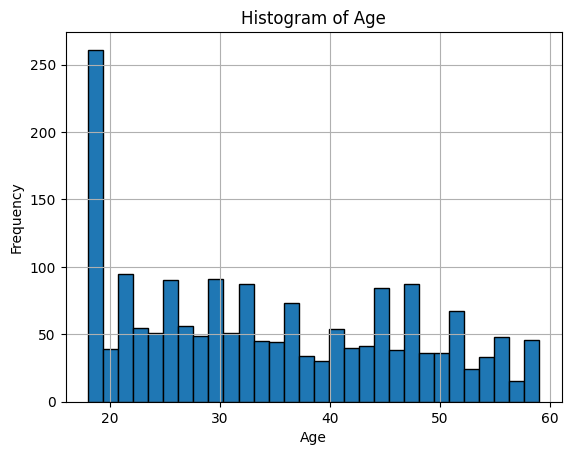

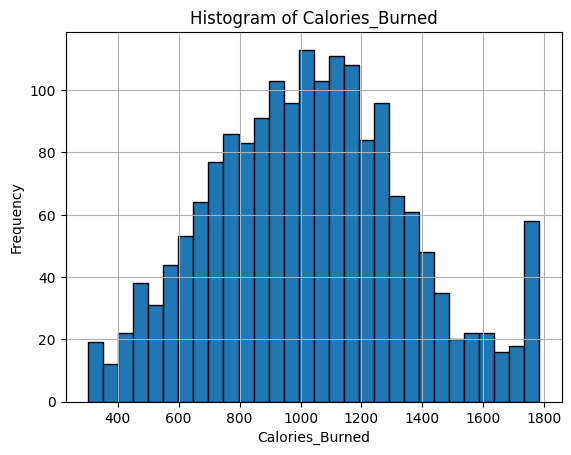

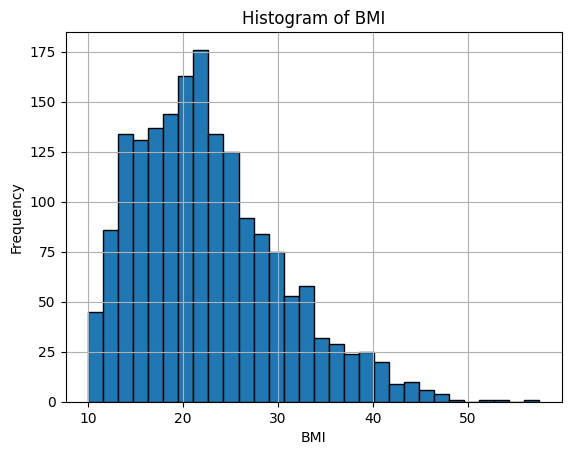

In [28]:
numeric_columns = ['Age', 'Calories_Burned', 'BMI']
for column in numeric_columns:
    plt.figure()
    df[column].hist(bins=30, edgecolor='black')
    plt.title(f'Histogram of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.show()

##  Step 10:Visualizing Outilers